# Weather Data Exploration - Jena Climate Dataset

This notebook explores the Jena Climate dataset for TCN-based weather prediction.

**Dataset**: Jena Climate 2009-2016 (Max Planck Institute for Biogeochemistry)
- 420,551 samples at 10-minute intervals
- 14 weather features
- 8 years of continuous data

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

print('Libraries imported successfully!')

## 1. Load Jena Climate Dataset

In [2]:
# Load the Jena Climate dataset
DATA_PATH = '../data/raw/jena_climate_2009_2016.csv'

df = pd.read_csv(DATA_PATH)
print(f'Dataset loaded successfully!')
print(f'Shape: {df.shape}')
df.head()

Dataset loaded successfully!
Shape: (420551, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [3]:
# Parse date and set as index
df['Date Time'] = pd.to_datetime(df['Date Time'], format='%d.%m.%Y %H:%M:%S')
df.set_index('Date Time', inplace=True)

print(f'Date range: {df.index.min()} to {df.index.max()}')
print(f'Duration: {(df.index.max() - df.index.min()).days} days')
df.head()

Date range: 2009-01-01 00:10:00 to 2017-01-01 00:00:00
Duration: 2921 days


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2009-01-01 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
2009-01-01 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2009-01-01 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
2009-01-01 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
2009-01-01 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


## 2. Data Overview & Quality Check

In [4]:
# Feature descriptions
feature_desc = {
    'p (mbar)': 'Atmospheric Pressure',
    'T (degC)': 'Temperature (Target)',
    'Tpot (K)': 'Potential Temperature',
    'Tdew (degC)': 'Dew Point Temperature',
    'rh (%)': 'Relative Humidity',
    'VPmax (mbar)': 'Saturation Vapor Pressure',
    'VPact (mbar)': 'Actual Vapor Pressure',
    'VPdef (mbar)': 'Vapor Pressure Deficit',
    'sh (g/kg)': 'Specific Humidity',
    'H2OC (mmol/mol)': 'Water Vapor Concentration',
    'rho (g/m**3)': 'Air Density',
    'wv (m/s)': 'Wind Velocity',
    'max. wv (m/s)': 'Maximum Wind Velocity',
    'wd (deg)': 'Wind Direction'
}

print('FEATURE DESCRIPTIONS')
print('='*60)
for col in df.columns:
    desc = feature_desc.get(col, 'Unknown')
    print(f'{col:20} | {desc}')

FEATURE DESCRIPTIONS
p (mbar)             | Atmospheric Pressure
T (degC)             | Temperature (Target)
Tpot (K)             | Potential Temperature
Tdew (degC)          | Dew Point Temperature
rh (%)               | Relative Humidity
VPmax (mbar)         | Saturation Vapor Pressure
VPact (mbar)         | Actual Vapor Pressure
VPdef (mbar)         | Vapor Pressure Deficit
sh (g/kg)            | Specific Humidity
H2OC (mmol/mol)      | Water Vapor Concentration
rho (g/m**3)         | Air Density
wv (m/s)             | Wind Velocity
max. wv (m/s)        | Maximum Wind Velocity
wd (deg)             | Wind Direction


In [5]:
# Check data types and missing values
print('DATA QUALITY CHECK')
print('='*60)
print(f'\nTotal samples: {len(df):,}')
print(f'Features: {len(df.columns)}')
print(f'\nMissing values:')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values!')

print('\nData types:')
print(df.dtypes)

DATA QUALITY CHECK

Total samples: 420,551
Features: 14

Missing values:
No missing values!

Data types:
p (mbar)           float64
T (degC)           float64
Tpot (K)           float64
Tdew (degC)        float64
rh (%)             float64
VPmax (mbar)       float64
VPact (mbar)       float64
VPdef (mbar)       float64
sh (g/kg)          float64
H2OC (mmol/mol)    float64
rho (g/m**3)       float64
wv (m/s)           float64
max. wv (m/s)      float64
wd (deg)           float64
dtype: object


In [6]:
# Statistical summary
df.describe().round(2)

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
count,420551.00,420551.00,420551.00,420551.00,420551.00,420551.00,420551.00,420551.00,420551.00,420551.00,420551.00,420551.00,420551.00,420551.00
mean,989.21,9.45,283.49,4.96,76.01,13.58,9.53,4.04,6.02,9.64,1216.06,1.70,3.06,174.74
std,8.36,8.42,8.50,6.73,16.48,7.74,4.18,4.90,2.66,4.24,39.98,65.45,69.02,86.68
min,913.60,-23.01,250.60,-25.01,12.95,0.95,0.79,0.00,0.50,0.80,1059.45,-9999.00,-9999.00,0.00
25%,984.20,3.36,277.43,0.24,65.21,7.78,6.21,0.87,3.92,6.29,1187.49,0.99,1.76,124.90
50%,989.58,9.42,283.47,5.22,79.30,11.82,8.86,2.19,5.59,8.96,1213.79,1.76,2.96,198.10
75%,994.72,15.47,289.53,10.07,89.40,17.60,12.35,5.30,7.80,12.49,1242.77,2.86,4.74,234.10
max,1015.35,37.28,311.34,23.11,100.00,63.77,28.32,46.01,18.13,28.82,1393.54,28.49,23.50,360.00


## 3. Time Series Visualization

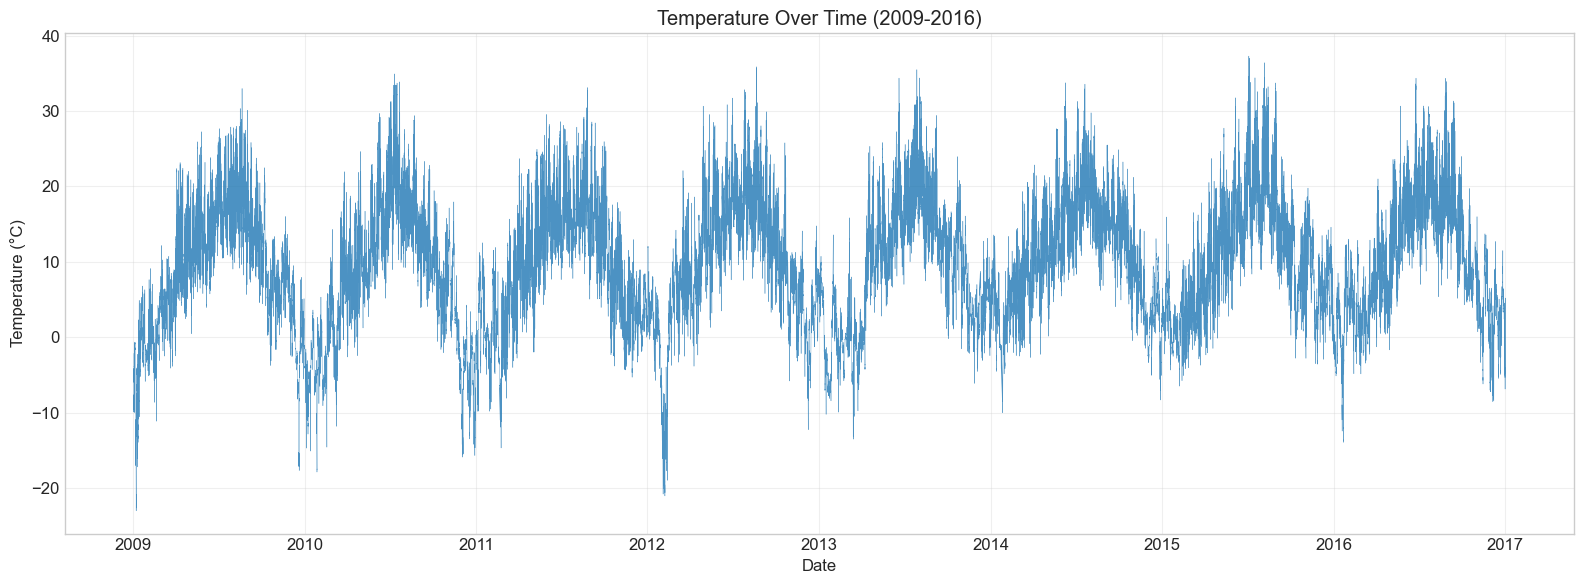

In [7]:
# Plot temperature over time (our target variable)
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(df.index, df['T (degC)'], linewidth=0.3, alpha=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Temperature Over Time (2009-2016)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/temperature_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()

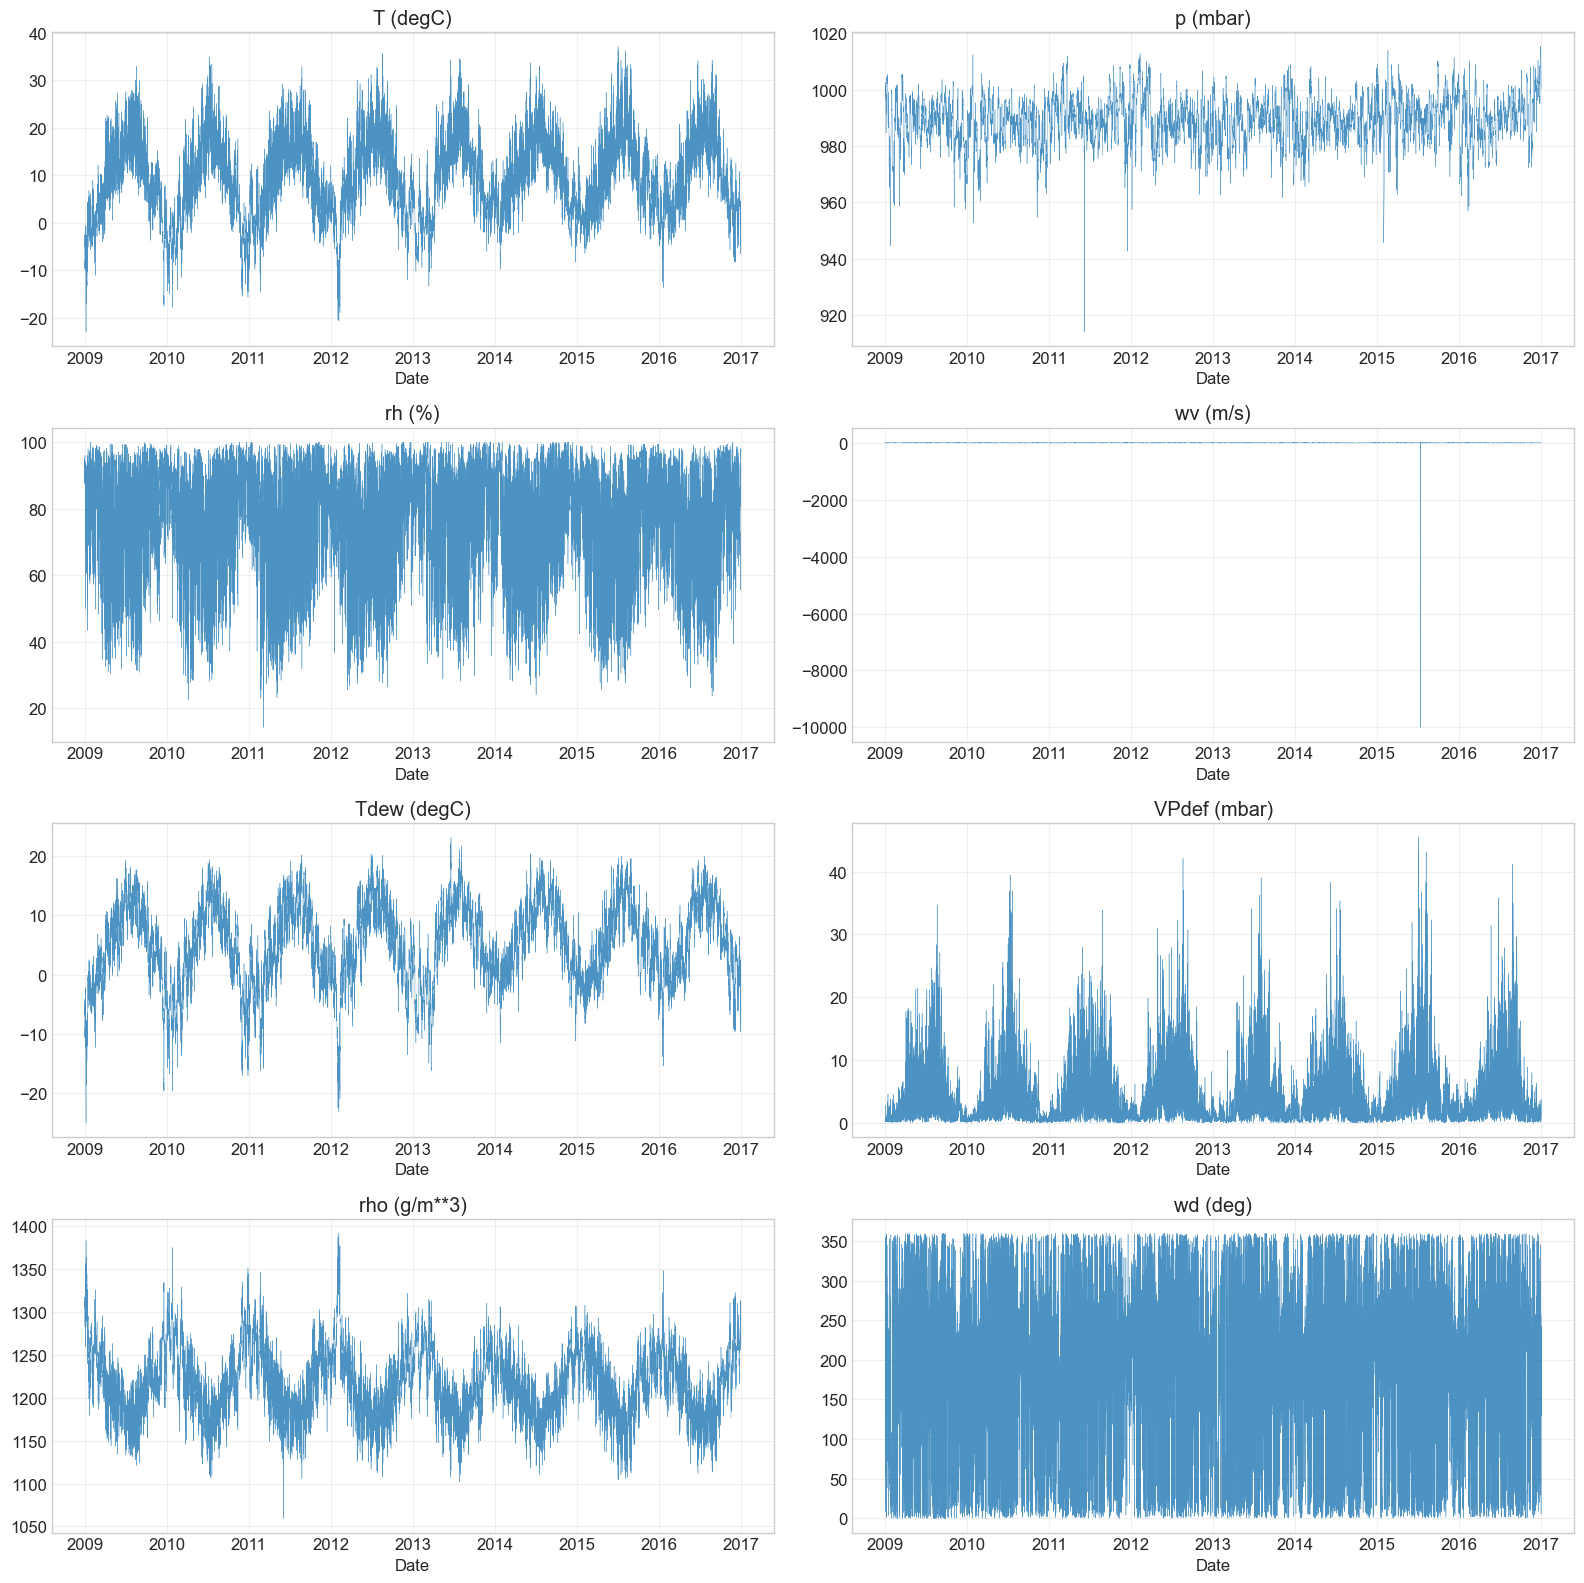

In [8]:
# Plot all features - subsample for clarity
df_sample = df[::6]  # Every hour instead of every 10 min

fig, axes = plt.subplots(4, 2, figsize=(16, 16))

key_features = ['T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 
                'Tdew (degC)', 'VPdef (mbar)', 'rho (g/m**3)', 'wd (deg)']

for ax, feature in zip(axes.flatten(), key_features):
    ax.plot(df_sample.index, df_sample[feature], linewidth=0.3, alpha=0.8)
    ax.set_title(f'{feature}')
    ax.set_xlabel('Date')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/all_features_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Correlation Analysis

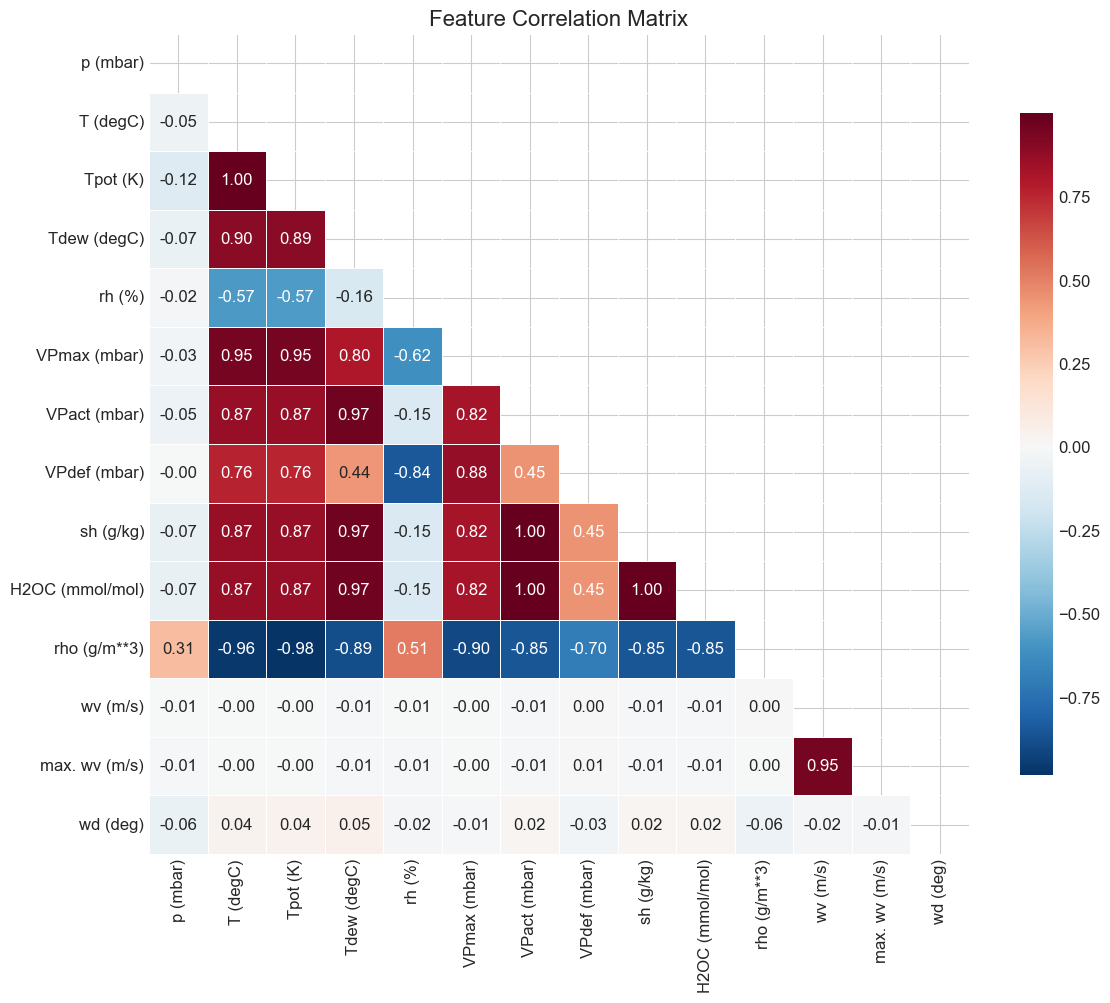


Correlations with Temperature (Target):
T (degC)           1.000000
Tpot (K)           0.996827
VPmax (mbar)       0.951113
Tdew (degC)        0.895708
VPact (mbar)       0.867673
H2OC (mmol/mol)    0.867177
sh (g/kg)          0.866755
VPdef (mbar)       0.761744
wd (deg)           0.038732
max. wv (m/s)     -0.002871
wv (m/s)          -0.004689
p (mbar)          -0.045375
rh (%)            -0.572416
rho (g/m**3)      -0.963410
Name: T (degC), dtype: float64


In [9]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
corr_matrix = df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0,
            fmt='.2f', square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})

plt.title('Feature Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.savefig('../outputs/figures/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Show correlations with temperature
print('\nCorrelations with Temperature (Target):')
print(corr_matrix['T (degC)'].sort_values(ascending=False))

## 5. Seasonal Patterns

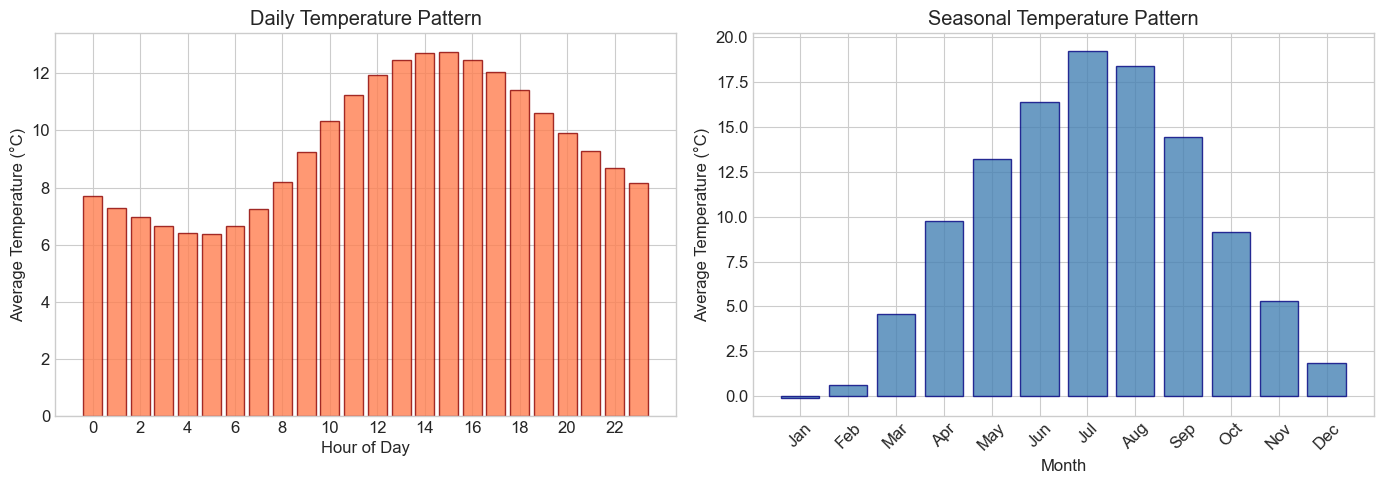

In [10]:
# Extract time components
df['hour'] = df.index.hour
df['month'] = df.index.month
df['year'] = df.index.year
df['dayofweek'] = df.index.dayofweek

# Daily pattern
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hourly pattern
hourly_temp = df.groupby('hour')['T (degC)'].mean()
axes[0].bar(hourly_temp.index, hourly_temp.values, color='coral', edgecolor='darkred', alpha=0.8)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Average Temperature (°C)')
axes[0].set_title('Daily Temperature Pattern')
axes[0].set_xticks(range(0, 24, 2))

# Monthly pattern
monthly_temp = df.groupby('month')['T (degC)'].mean()
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes[1].bar(range(1, 13), monthly_temp.values, color='steelblue', edgecolor='navy', alpha=0.8)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Average Temperature (°C)')
axes[1].set_title('Seasonal Temperature Pattern')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(months, rotation=45)

plt.tight_layout()
plt.savefig('../outputs/figures/seasonal_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Data Preprocessing for TCN

In [12]:
# Resample to hourly data (reduces data size and noise)
# Original: 10-minute intervals = 420,551 samples
# Hourly: 70,091 samples - more manageable for training

df_hourly = df.resample('h').mean()
print(f'Resampled from {len(df):,} to {len(df_hourly):,} samples (hourly)')

# Drop time component columns we added
df_hourly = df_hourly.drop(['hour', 'month', 'year', 'dayofweek'], axis=1)
df_hourly.head()

Resampled from 420,551 to 70,129 samples (hourly)


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2009-01-01 00:00:00,996.528000,-8.304000,265.118000,-9.120000,93.780000,3.260000,3.058000,0.202000,1.910000,3.068000,1309.196000,0.520000,1.002000,174.460000
2009-01-01 01:00:00,996.525000,-8.065000,265.361667,-8.861667,93.933333,3.323333,3.121667,0.201667,1.951667,3.133333,1307.981667,0.316667,0.711667,172.416667
2009-01-01 02:00:00,996.745000,-8.763333,264.645000,-9.610000,93.533333,3.145000,2.940000,0.201667,1.836667,2.950000,1311.816667,0.248333,0.606667,196.816667
2009-01-01 03:00:00,996.986667,-8.896667,264.491667,-9.786667,93.200000,3.111667,2.898333,0.210000,1.811667,2.906667,1312.813333,0.176667,0.606667,157.083333
2009-01-01 04:00:00,997.158333,-9.348333,264.026667,-10.345000,92.383333,3.001667,2.775000,0.231667,1.733333,2.780000,1315.355000,0.290000,0.670000,150.093333


In [13]:
# Check for any missing values after resampling
print('Missing values after resampling:')
print(df_hourly.isnull().sum())

# Fill any missing values with interpolation
df_hourly = df_hourly.interpolate(method='linear')
print('\nAfter interpolation:', df_hourly.isnull().sum().sum(), 'missing values')

Missing values after resampling:
p (mbar)           88
T (degC)           88
Tpot (K)           88
Tdew (degC)        88
rh (%)             88
VPmax (mbar)       88
VPact (mbar)       88
VPdef (mbar)       88
sh (g/kg)          88
H2OC (mmol/mol)    88
rho (g/m**3)       88
wv (m/s)           88
max. wv (m/s)      88
wd (deg)           88
dtype: int64

After interpolation: 0 missing values


In [14]:
# Import our preprocessing module
import sys
sys.path.append('..')

from src.data.dataset import preprocess_data, create_dataloaders

# Select features for modeling
# We'll use all features but predict temperature
feature_cols = ['T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 
                'Tdew (degC)', 'VPdef (mbar)', 'rho (g/m**3)', 'sh (g/kg)']

df_model = df_hourly[feature_cols].copy()
print(f'Selected {len(feature_cols)} features for modeling')
print(f'Target: Temperature (T (degC)) - column index 0')

Selected 8 features for modeling
Target: Temperature (T (degC)) - column index 0


In [15]:
# Preprocess data: normalize and split
train_data, val_data, test_data, scaler = preprocess_data(
    df_model,
    train_ratio=0.7,
    val_ratio=0.15,
    handle_missing='interpolate'
)

print('DATA SPLIT SUMMARY')
print('='*40)
print(f'Training samples:   {len(train_data):,} ({len(train_data)/len(df_model)*100:.1f}%)')
print(f'Validation samples: {len(val_data):,} ({len(val_data)/len(df_model)*100:.1f}%)')
print(f'Test samples:       {len(test_data):,} ({len(test_data)/len(df_model)*100:.1f}%)')
print(f'\nFeatures: {train_data.shape[1]}')

DATA SPLIT SUMMARY
Training samples:   49,090 (70.0%)
Validation samples: 10,519 (15.0%)
Test samples:       10,520 (15.0%)

Features: 8


In [16]:
# Create PyTorch DataLoaders
SEQUENCE_LENGTH = 168  # 7 days of hourly data
FORECAST_HORIZON = 24  # Predict 24 hours ahead
BATCH_SIZE = 64
TARGET_COL = 0  # Temperature

train_loader, val_loader, test_loader = create_dataloaders(
    train_data, val_data, test_data,
    sequence_length=SEQUENCE_LENGTH,
    forecast_horizon=FORECAST_HORIZON,
    batch_size=BATCH_SIZE,
    target_col=TARGET_COL
)

print('DATALOADER CONFIGURATION')
print('='*40)
print(f'Sequence length: {SEQUENCE_LENGTH} hours (7 days)')
print(f'Forecast horizon: {FORECAST_HORIZON} hours (1 day)')
print(f'Batch size: {BATCH_SIZE}')
print(f'\nTraining batches:   {len(train_loader)}')
print(f'Validation batches: {len(val_loader)}')
print(f'Test batches:       {len(test_loader)}')

# Verify shapes
for batch_x, batch_y in train_loader:
    print(f'\nInput shape:  {batch_x.shape}  (batch, sequence, features)')
    print(f'Target shape: {batch_y.shape}  (batch, forecast_horizon)')
    break

DATALOADER CONFIGURATION
Sequence length: 168 hours (7 days)
Forecast horizon: 24 hours (1 day)
Batch size: 64

Training batches:   765
Validation batches: 162
Test batches:       162

Input shape:  torch.Size([64, 168, 8])  (batch, sequence, features)
Target shape: torch.Size([64, 24])  (batch, forecast_horizon)


## 7. Save Processed Data

In [17]:
# Save processed dataframe for later use
df_model.to_csv('../data/raw/jena_climate_processed.csv')
print('Processed data saved to: data/raw/jena_climate_processed.csv')

# Save scaler for inference
import pickle
with open('../outputs/models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('Scaler saved to: outputs/models/scaler.pkl')

Processed data saved to: data/raw/jena_climate_processed.csv
Scaler saved to: outputs/models/scaler.pkl


## 8. Summary for Report

In [18]:
print('='*70)
print('DATASET SUMMARY FOR REPORT')
print('='*70)
print(f'''
DATASET INFORMATION
-------------------
Name: Jena Climate Dataset (Max Planck Institute for Biogeochemistry)
Source: Kaggle (https://www.kaggle.com/datasets/mnassrib/jena-climate)
Time Range: 2009-01-01 to 2016-12-31 (8 years)
Original Frequency: 10-minute intervals
Total Original Samples: {len(df):,}

PREPROCESSING
-------------
Resampling: 10-min → Hourly (averaging)
Processed Samples: {len(df_hourly):,}
Normalization: StandardScaler (z-score)
Missing Value Handling: Linear Interpolation

FEATURES SELECTED ({len(feature_cols)})
-----------------
- T (degC): Temperature (TARGET)
- p (mbar): Atmospheric Pressure
- rh (%): Relative Humidity
- wv (m/s): Wind Velocity
- Tdew (degC): Dew Point Temperature
- VPdef (mbar): Vapor Pressure Deficit
- rho (g/m**3): Air Density
- sh (g/kg): Specific Humidity

DATA SPLIT
----------
Training:   {len(train_data):,} samples (70%)
Validation: {len(val_data):,} samples (15%)
Test:       {len(test_data):,} samples (15%)

MODEL INPUT CONFIGURATION
-------------------------
Input Sequence: {SEQUENCE_LENGTH} hours (7 days of history)
Forecast Horizon: {FORECAST_HORIZON} hours (1 day prediction)
Batch Size: {BATCH_SIZE}
''')

DATASET SUMMARY FOR REPORT

DATASET INFORMATION
-------------------
Name: Jena Climate Dataset (Max Planck Institute for Biogeochemistry)
Source: Kaggle (https://www.kaggle.com/datasets/mnassrib/jena-climate)
Time Range: 2009-01-01 to 2016-12-31 (8 years)
Original Frequency: 10-minute intervals
Total Original Samples: 420,551

PREPROCESSING
-------------
Resampling: 10-min → Hourly (averaging)
Processed Samples: 70,129
Normalization: StandardScaler (z-score)
Missing Value Handling: Linear Interpolation

FEATURES SELECTED (8)
-----------------
- T (degC): Temperature (TARGET)
- p (mbar): Atmospheric Pressure
- rh (%): Relative Humidity
- wv (m/s): Wind Velocity
- Tdew (degC): Dew Point Temperature
- VPdef (mbar): Vapor Pressure Deficit
- rho (g/m**3): Air Density
- sh (g/kg): Specific Humidity

DATA SPLIT
----------
Training:   49,090 samples (70%)
Validation: 10,519 samples (15%)
Test:       10,520 samples (15%)

MODEL INPUT CONFIGURATION
-------------------------
Input Sequence: 168 h

---

## Next Steps

1. **Proceed to Model Training Notebook** (`02_model_training.ipynb`)
2. Train baseline LSTM model
3. Train TCN model
4. Compare results and visualize predictions